## Ex 02 - Developing a Neural Network Classification Model
**Name:** kolluru pujitha

**Reg.No:** 212223240074

**Slot:** 26OD1143

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
class Model(nn.Module):
    
    def __init__(self, in_features=4, h1=8, h2=9, out_features=3): # How many Layers?

        # Input Layers (4 futures) ---> h1 N--> N---> output (3 class)
        
        super().__init__()
        self.fc1 = nn.Linear(in_features,h1)    # input layer
        self.fc2 = nn.Linear(h1, h2)            # hidden layer
        self.out = nn.Linear(h2, out_features)  # output layer
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

In [3]:
# Instantiate the Model class using parameter defaults:
torch.manual_seed(32)
model = Model()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
df = pd.read_csv('iris.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [6]:
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

In [18]:
X = df.drop('species', axis=1)
y = df['species']

In [19]:
type(X)

pandas.DataFrame

In [20]:
X = X.values
y = y.values

In [21]:
type(X)

numpy.ndarray

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [27]:
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [28]:
criterion = nn.CrossEntropyLoss()  # multi class clasification problem 
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)   # 0.000001

In [29]:
model.parameters

<bound method Module.parameters of Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)>

In [30]:
epochs = 100
losses = []
for i in range(epochs):
    i+=1
    # Forward and get a prediction 
    y_pred = model.forward(X_train)
    #Calculation Loss/error
    loss = criterion(y_pred, y_train)
    losses.append(loss.item())
    # a neat trick to save screen space:
    if i%10 == 1:
        print(f'epoch: {i}  loss: {loss.item()}')
    #Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

epoch: 1  loss: 1.1609848737716675
epoch: 11  loss: 0.9522749185562134
epoch: 21  loss: 0.790829598903656
epoch: 31  loss: 0.6282720565795898
epoch: 41  loss: 0.42801162600517273
epoch: 51  loss: 0.27990370988845825
epoch: 61  loss: 0.1643649786710739
epoch: 71  loss: 0.10284613072872162
epoch: 81  loss: 0.0779661163687706
epoch: 91  loss: 0.06790287792682648


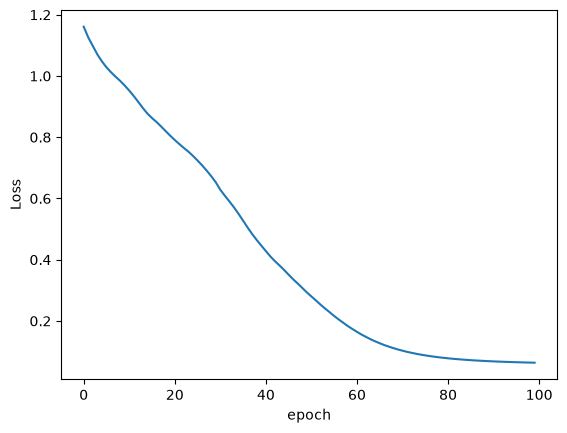

In [31]:
plt.plot(range(epochs), losses)
plt.ylabel('Loss')
plt.xlabel('epoch');

In [32]:
correct = 0
with torch.no_grad():
    for i,data in enumerate(X_test):
        y_val =model.forward(data)
        #1.) 2.) 3.)
        print(f'{i+1}.) {str(y_val)} {y_test[i]}')
        # 0 1 2
        if y_val.argmax().item() == y_test[i]:
            correct +=1
print(f'We got {correct} correct!')

1.) tensor([-3.1926,  4.4545, -0.0541]) 1
2.) tensor([  7.8744,   1.6003, -12.4815]) 0
3.) tensor([-12.9323,   1.1515,  11.6760]) 2
4.) tensor([-3.7355,  3.9947,  0.7765]) 1
5.) tensor([-3.9229,  4.4761,  0.6612]) 1
6.) tensor([  7.1179,   1.5594, -11.4037]) 0
7.) tensor([-0.4279,  4.2162, -2.8544]) 1
8.) tensor([-8.0310,  2.5306,  6.0510]) 2
9.) tensor([-6.0241,  2.9879,  3.8209]) 1
10.) tensor([-1.3616,  4.3996, -1.9424]) 1
11.) tensor([-6.5539,  3.0901,  4.1901]) 2
12.) tensor([  6.9068,   1.3622, -10.9203]) 0
13.) tensor([  7.9975,   1.3602, -12.4142]) 0
14.) tensor([  6.9953,   1.4174, -11.0959]) 0
15.) tensor([  7.7919,   1.3447, -12.1170]) 0
16.) tensor([-3.2079,  4.4844, -0.1192]) 1
17.) tensor([-9.8826,  1.7023,  8.4129]) 2
18.) tensor([-1.7055,  4.3201, -1.4898]) 1
19.) tensor([-3.3576,  4.0562,  0.3714]) 1
20.) tensor([-9.8735,  1.5346,  8.5005]) 2
21.) tensor([  6.7092,   1.4420, -10.7277]) 0
22.) tensor([-5.9823,  3.0984,  3.6301]) 2
23.) tensor([  6.7725,   1.5291, -10.90

In [33]:
 print(f'{i+1}.) {str(y_val.argmax().item())} {y_test[i]}')

30.) 0 0


In [34]:
torch.save(model.state_dict(),'my_iris_model.pt')